In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#2. Load Dataset
data = pd.read_excel("/content/coconut_data.xlsx")  # change file name if needed

print(data.head())
print(data.columns)

   Rainfall  Temperature    yeilds  Humidity    Crops
0    2903.1         27.0    2570.0      57.0  Coconut
1    2903.1         27.0   27170.0      57.5  Coconut
2    2903.1         27.0  114744.0      57.0  Coconut
3    2996.6         27.0    1402.0      55.0  Coconut
4    2996.6         27.0   23456.0      56.0  Coconut
Index(['Rainfall', 'Temperature', 'yeilds', 'Humidity', 'Crops'], dtype='object')


In [ ]:
X = data[['Rainfall', 'Humidity', 'Temperature']]
y = data['yeilds']

In [ ]:
#4. Train-Test Split
from sklearn.model_selection import train_test_split

X = data[['Rainfall', 'Humidity', 'Temperature']]
y = data['yeilds']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(data.shape)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1458, 5)
(1166, 3)
(1166,)
(292, 3)
(292,)


In [ ]:
import numpy as np
x_mean=np.mean(X_train)
y_mean=np.mean(y_train)
print(x_mean,y_mean)

938.4793024585476 33440.16615780446


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Intercept:", lr_model.intercept_)
print("Coefficients:", lr_model.coef_)

Intercept: 33440.16615780446
Coefficients: [-2980.66743116   820.43764333   793.45176514]


In [ ]:
y_predHD = lr_model.predict(sc_X.transform([[30.8, 10.9, 27.0]])) # Use lr_model and scale the input
print(y_predHD)

[24346.15489001]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_lr=lr_model.predict(X_test)
print("Predicted:", y_pred_lr[0:5])
print("Actual:", y_test.values[0:5])

Predicted: [31609.88716489 32263.57133423 32425.88494493 30333.07044898
 33506.62820033]
Actual: [4.0400000e+02 3.8990000e+03 7.1000000e+01 1.7173900e+05 1.1782584e+05]


In [ ]:
from sklearn import metrics
# Error calculations for Linear Regression
print("Linear Regression Metrics:")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_lr))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", metrics.r2_score(y_test, y_pred_lr))

Linear Regression Metrics:
MAE: 44378.933600614895
MSE: 4445920572.114857
RMSE: 66677.73670510163
R2 Score: -0.0012530553898806307


In [ ]:
#Artificail Neural Network
from sklearn.neural_network import MLPRegressor
# Removed redundant X, y definition to use the consistent split from above.

In [ ]:
# Removed redundant train_test_split call to use the consistent split from above.

In [ ]:
ann_model = MLPRegressor(hidden_layer_sizes=(6,6), max_iter=500)
#Two hidden layers with 6 neurons each
#Number of training iterations
ann_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(6, 6), max_iter=500)

In [ ]:
y_pred_ann=ann_model.predict(X_test)
print("Predicted:", y_pred_ann[0:5])
print("Actual:", y_test.values[0:5])

Predicted: [1815.05623709 2078.55601187 1489.4711054  2369.73130387 1797.39394715]
Actual: [4.0400000e+02 3.8990000e+03 7.1000000e+01 1.7173900e+05 1.1782584e+05]


In [ ]:
# Error calculations for ANN
print("ANN Metrics:")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred_ann))
print("MSE:", metrics.mean_squared_error(y_test, y_pred_ann))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred_ann)))
print("R2 Score:", metrics.r2_score(y_test, y_pred_ann))

ANN Metrics:
MAE: 36674.82067547
MSE: 5668652085.188415
RMSE: 75290.4514874789
R2 Score: -0.2766209220731193


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Random Forest Regression
# ==============================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("R2 Score:", r2_score(y_test, rf_pred))

Random Forest Results:
MSE: 4368878103.068297
R2 Score: 0.016097458699702805


In [ ]:
#hyper parameter tuning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Create base model
rf = RandomForestRegressor(random_state=42)
# Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [ ]:
# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=2
)


In [ ]:
# Train
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [ ]:
# Best model
best_rf = grid_search.best_estimator_


In [ ]:
# Predictions
y_pred = best_rf.predict(X_test)


In [ ]:
# Evaluation
print("Best Parameters:", grid_search.best_params_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
MSE: 4147732889.957554
R2 Score: 0.06590093960324295


In [ ]:
import pandas as pd

best_params = grid_search.best_params_

# Convert to table
best_table = pd.DataFrame([best_params])

print(best_table)

# Save
best_table.to_csv("best_rf_parameters.csv", index=False)

   max_depth  min_samples_leaf  min_samples_split  n_estimators
0         10                 4                 10           200


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

#2. Decision Tree Regression
# ==============================
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\nDecision Tree Results:")
print("MSE:", mean_squared_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))


Decision Tree Results:
MSE: 7129546742.114423
R2 Score: -0.6056248291658906


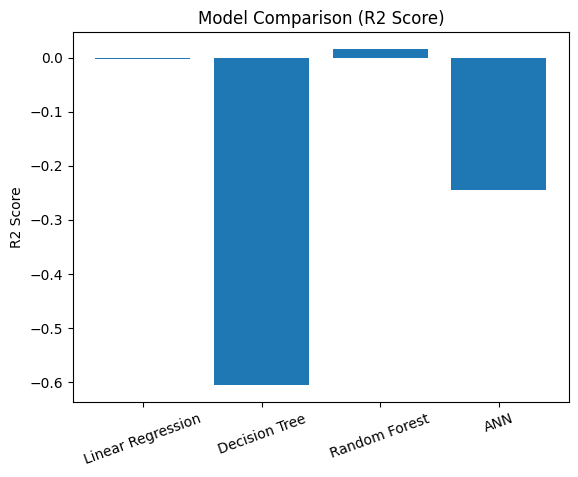

In [ ]:
#9. Model Comparison Graph
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'ANN']

r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred),
    r2_score(y_test, y_pred_ann)
]
plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

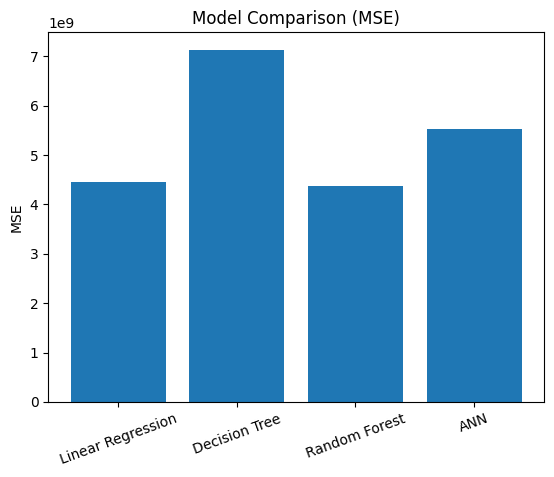

In [ ]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'ANN']

mse_scores = [
    metrics.mean_squared_error(y_test, y_pred_lr),
    metrics.mean_squared_error(y_test, dt_pred),
    metrics.mean_squared_error(y_test, rf_pred),
    metrics.mean_squared_error(y_test, y_pred_ann)
]
plt.bar(models, mse_scores)
plt.title("Model Comparison (MSE)")
plt.ylabel("MSE")
plt.xticks(rotation=20)
plt.show()

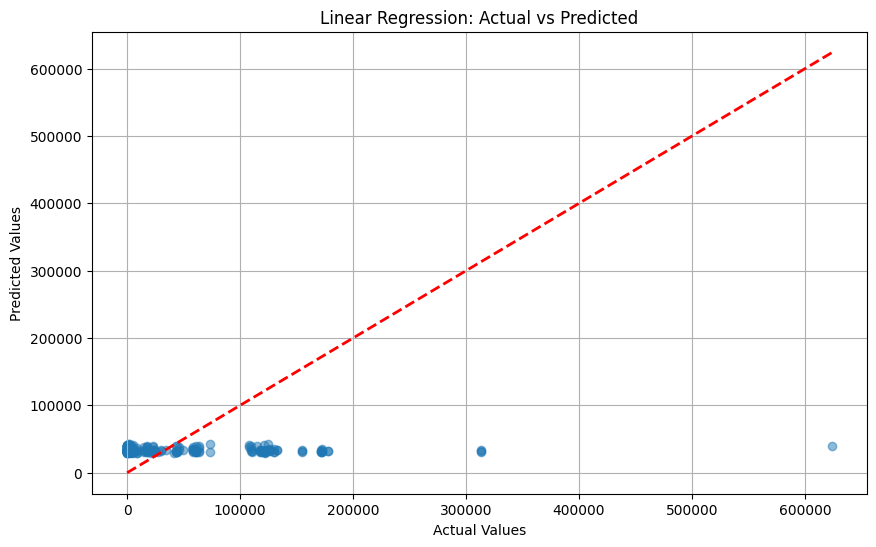

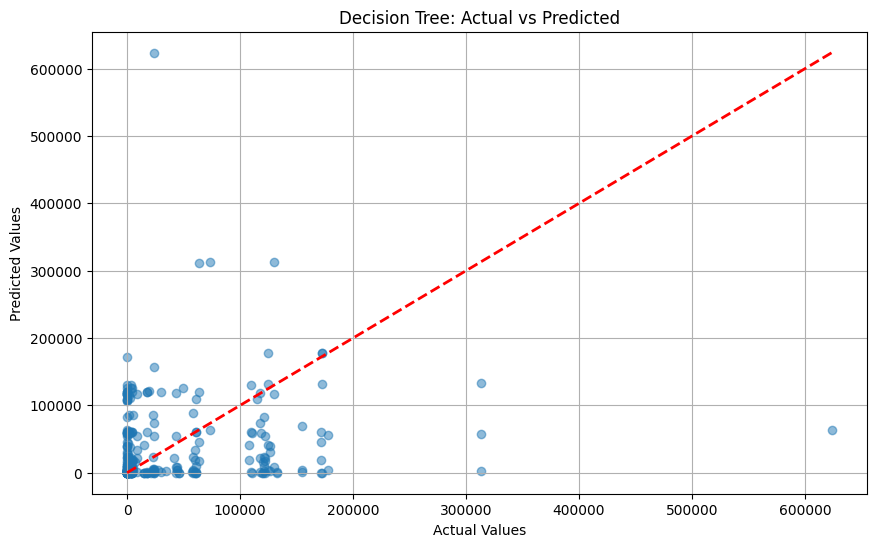

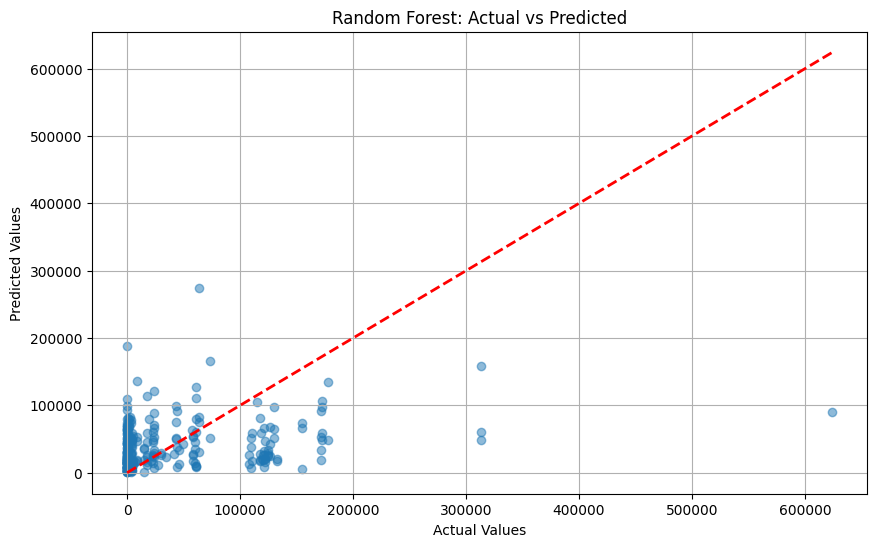

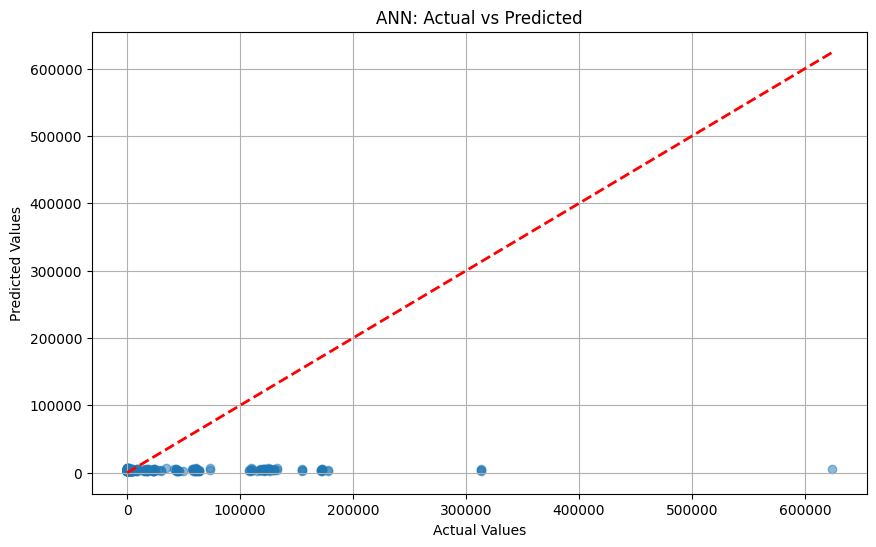

In [ ]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2) # Diagonal line
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)
    plt.grid(True)
    plt.show()

#plot graph for each model
plot_actual_vs_predicted(y_test, y_pred_lr, "Linear Regression: Actual vs Predicted")
plot_actual_vs_predicted(y_test, dt_pred, "Decision Tree: Actual vs Predicted")
plot_actual_vs_predicted(y_test, rf_pred, "Random Forest: Actual vs Predicted")
plot_actual_vs_predicted(y_test, y_pred_ann, "ANN: Actual vs Predicted")